# Quantum Bayesian Network Sampling (`pyagrum.qBNSampling`)


| | | | | |
|-|-|-|-|-|
| [![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) | [![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fnotebooks%2F74-PyModels_QBNSampling.ipynb) |[![download notebook](images/atdownload.svg)](https://pyagrum.readthedocs.io/en/latest/notebooks/74-PyModels_QBNSampling.ipynb) |[![open in colab](images/atcolab.svg)](https://colab.research.google.com/github/agrumery/aGrUM/blob/master/wrappers/pyagrum/doc/sphinx/notebooks/74-PyModels_QBNSampling.ipynb) |


The `pyagrum.qBNSampling` module encodes a Bayesian network as a quantum circuit
so that measuring the circuit samples from the network's joint distribution.
It also provides a quantum rejection-sampling inference engine that computes
posterior distributions conditioned on evidence using Grover-based amplitude
amplification.

**Dependencies**: `qiskit`, `qiskit-aer`, `qiskit-ibm-runtime`, `scipy`.

**References**
- Circuit encoding: Borujeni et al., *Quantum circuit representation of Bayesian networks*, Expert Systems with Applications, 2021. [arXiv:2004.14803](https://arxiv.org/abs/2004.14803)
- Quantum inference: Low, Yoder, Chuang, *Quantum inference on Bayesian networks*, Physical Review A, 2014. [arXiv:1402.7359](https://arxiv.org/abs/1402.7359)


In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.qBNSampling as qBNS

## Part 1 — `qBNMC`: encoding a Bayesian network as a quantum circuit

Each variable in the BN is mapped to $\lceil \log_2(|\text{dom}|) \rceil$ qubits.
Its CPT is encoded as multi-qubit RY rotations: root nodes get unconditional
rotations; non-root nodes get controlled rotations — one block per parent
configuration, framed by X gates to select the correct control state.

Measuring the circuit returns a sample from the joint distribution of the network.


### Illustrative example: 3-node BN


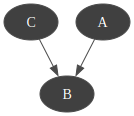

In [2]:
bn = gum.fastBN("A->B<-C", 2)
gnb.showBN(bn)

In [3]:
qbn = qBNS.qBNMC(bn)

print(f"Total qubits: {qbn.getTotNumQBits()}")
print(f"Qubit map (node id -> qubit ids): {qbn.n_qb_map}")

circuit = qbn.buildCircuit(add_measure=True)

Total qubits: 3
Qubit map (node id -> qubit ids): {0: [0], 1: [1], 2: [2]}


Running the circuit on the Aer simulator returns marginal probability vectors
for each variable. Let us compare them with the exact marginals from
`LazyPropagation`.



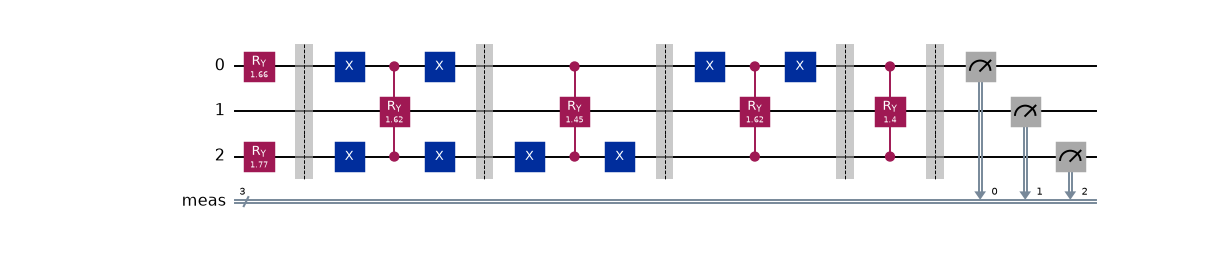

In [4]:
gnb.flow.row(gnb.getBN(bn), circuit.draw("mpl", scale=0.7))

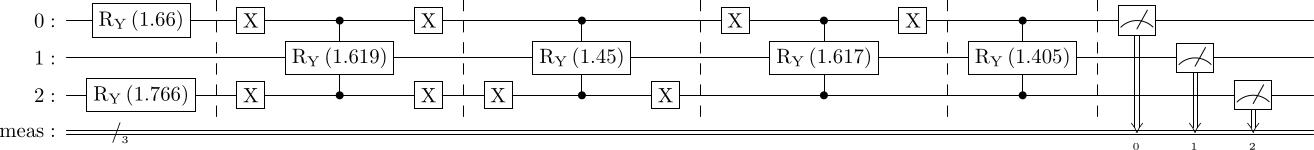

In [5]:
circuit.draw("latex")

In [6]:
circuit.draw()

┌────────────┐ ░ ┌───┐              ┌───┐ ░                          ░ »
     0: ┤ Ry(1.6603) ├─░─┤ X ├──────■───────┤ X ├─░────────────■─────────────░─»
        └────────────┘ ░ └───┘┌─────┴──────┐└───┘ ░      ┌─────┴──────┐      ░ »
     1: ───────────────░──────┤ Ry(1.6194) ├──────░──────┤ Ry(1.4498) ├──────░─»
        ┌────────────┐ ░ ┌───┐└─────┬──────┘┌───┐ ░ ┌───┐└─────┬──────┘┌───┐ ░ »
     2: ┤ Ry(1.7663) ├─░─┤ X ├──────■───────┤ X ├─░─┤ X ├──────■───────┤ X ├─░─»
        └────────────┘ ░ └───┘              └───┘ ░ └───┘              └───┘ ░ »
meas: 3/═══════════════════════════════════════════════════════════════════════»
                                                                               »
«        ┌───┐              ┌───┐ ░                ░ ┌─┐      
«     0: ┤ X ├──────■───────┤ X ├─░───────■────────░─┤M├──────
«        └───┘┌─────┴──────┐└───┘ ░ ┌─────┴──────┐ ░ └╥┘┌─┐   
«     1: ─────┤ Ry(1.6169) ├──────░─┤ Ry(1.4045) ├─░──╫─┤M├───
«             └─────┬──────┘      ░ └─────┬──────┘ ░  ║ └╥┘┌─┐
«     2: ───────────■─────────────░───────■────────░──╫──╫─┤M├
«                                 ░                ░  ║  ║ └╥┘
«meas: 3/═════════════════════════════════════════════╩══╩══╩═
«                                                     0  1  2

In [7]:
marginals = qbn.runBN(shots=10000)

In [8]:
ie = gum.LazyPropagation(bn)
ie.makeInference()

for name, tensor in marginals.items():
  print(f"P({name})")
  print(f"  qBNMC (10 000 shots) : {[round(v, 4) for v in tensor.tolist()]}")
  print(f"  LazyPropagation      : {[round(v, 4) for v in ie.posterior(name).tolist()]}")
  print()

P(A)
  qBNMC (10 000 shots) : [0.456, 0.544]
  LazyPropagation      : [0.4553, 0.5447]

P(B)
  qBNMC (10 000 shots) : [0.5246, 0.4754]
  LazyPropagation      : [0.5294, 0.4706]

P(C)
  qBNMC (10 000 shots) : [0.3925, 0.6075]
  LazyPropagation      : [0.4029, 0.5971]



### Named example: Oil Company Stock Price (Borujeni et al., 2021)

A 4-node BN modelling the dependencies between Interest Rate (IR),
Stock Market (SM), Oil Import (OI), and Stock Price (SP).


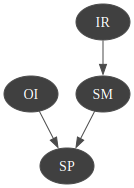

In [9]:
bn_oil = gum.fastBN("IR->SM->SP<-OI", 2)
bn_oil.cpt("IR")[:] = [0.75, 0.25]
bn_oil.cpt("SM")[:] = [[0.3, 0.7], [0.8, 0.2]]
bn_oil.cpt("OI")[:] = [0.6, 0.4]
bn_oil.cpt("SP")[:] = [[[0.1, 0.9], [0.3, 0.7]], [[0.4, 0.6], [0.7, 0.3]]]

gnb.showBN(bn_oil)

In [10]:
qbn_oil = qBNS.qBNMC(bn_oil)
print(f"Total qubits: {qbn_oil.getTotNumQBits()}")
qbn_oil.buildCircuit().draw("text")

Total qubits: 4


┌─────────┐   ░ ┌───┐              ┌───┐ ░                ░      »
     0: ─┤ Ry(π/3) ├───░─┤ X ├──────■───────┤ X ├─░───────■────────░──────»
         └─────────┘   ░ └───┘┌─────┴──────┐└───┘ ░ ┌─────┴──────┐ ░ ┌───┐»
     1: ───────────────░──────┤ Ry(1.9823) ├──────░─┤ Ry(0.9273) ├─░─┤ X ├»
                       ░      └────────────┘      ░ └────────────┘ ░ └───┘»
     2: ───────────────░──────────────────────────░────────────────░──────»
        ┌────────────┐ ░                          ░                ░ ┌───┐»
     3: ┤ Ry(1.3694) ├─░──────────────────────────░────────────────░─┤ X ├»
        └────────────┘ ░                          ░                ░ └───┘»
meas: 4/══════════════════════════════════════════════════════════════════»
                                                                          »
«                            ░                          ░                    »
«     0: ────────────────────░──────────────────────────░────────────────────»
«                      ┌───┐ ░                          ░ ┌───┐              »
«     1: ──────■───────┤ X ├─░────────────■─────────────░─┤ X ├──────■───────»
«        ┌─────┴──────┐└───┘ ░      ┌─────┴──────┐      ░ └───┘┌─────┴──────┐»
«     2: ┤ Ry(2.4981) ├──────░──────┤ Ry(1.9823) ├──────░──────┤ Ry(1.7722) ├»
«        └─────┬──────┘┌───┐ ░ ┌───┐└─────┬──────┘┌───┐ ░      └─────┬──────┘»
«     3: ──────■───────┤ X ├─░─┤ X ├──────■───────┤ X ├─░────────────■───────»
«                      └───┘ ░ └───┘              └───┘ ░                    »
«meas: 4/════════════════════════════════════════════════════════════════════»
«                                                                            »
«              ░                ░ ┌─┐         
«     0: ──────░────────────────░─┤M├─────────
«        ┌───┐ ░                ░ └╥┘┌─┐      
«     1: ┤ X ├─░───────■────────░──╫─┤M├──────
«        └───┘ ░ ┌─────┴──────┐ ░  ║ └╥┘┌─┐   
«     2: ──────░─┤ Ry(1.1593) ├─░──╫──╫─┤M├───
«              ░ └─────┬──────┘ ░  ║  ║ └╥┘┌─┐
«     3: ──────░───────■────────░──╫──╫──╫─┤M├
«              ░                ░  ║  ║  ║ └╥┘
«meas: 4/══════════════════════════╩══╩══╩══╩═
«                                  0  1  2  3

In [11]:
marginals_oil = qbn_oil.runBN(shots=10000)

In [12]:
ie_oil = gum.LazyPropagation(bn_oil)
ie_oil.makeInference()

gnb.sideBySide(
  marginals_oil["SP"],
  ie_oil.posterior("SP"),
  captions=["qBNMC — 10 000 shots", "LazyPropagation — exact"],
)

### Multi-state variables: Naive Bayes Bankruptcy Prediction

Variables with more than 2 states require $\lceil \log_2(|\text{dom}|) \rceil > 1$ qubits.
Here node `B` has 2 states and several children have 3 states (2 qubits each).


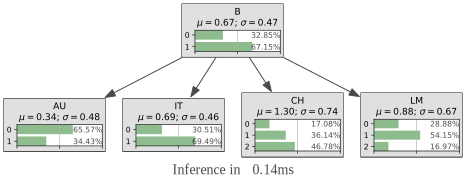

In [13]:
bn_bk = gum.fastBN("B->AU; B->IT; B->CH[3]; B->LM[3]")
bn_bk.generateCPTs()
gnb.showInference(bn_bk)

In [14]:
qbn_bk = qBNS.qBNMC(bn_bk)
print(f"Total qubits: {qbn_bk.getTotNumQBits()}")
print(f"Qubit widths: { {bn_bk.variable(n).name(): qbn_bk.getWidth(n) for n in bn_bk.nodes()} }")
qbn_bk.buildCircuit().draw("text")

Total qubits: 7
Qubit widths: {'B': 1, 'AU': 1, 'IT': 1, 'CH': 2, 'LM': 2}


┌────────────┐ ░ ┌───┐              ┌───┐ ░                ░ ┌───┐»
     0: ┤ Ry(1.9209) ├─░─┤ X ├──────■───────┤ X ├─░───────■────────░─┤ X ├»
        └────────────┘ ░ └───┘      │       └───┘ ░       │        ░ └───┘»
     1: ───────────────░────────────┼─────────────░───────┼────────░──────»
                       ░      ┌─────┴──────┐      ░ ┌─────┴──────┐ ░      »
     2: ───────────────░──────┤ Ry(2.2354) ├──────░─┤ Ry(1.8533) ├─░──────»
                       ░      └────────────┘      ░ └────────────┘ ░      »
   3_0: ───────────────░──────────────────────────░────────────────░──────»
                       ░                          ░                ░      »
   3_1: ───────────────░──────────────────────────░────────────────░──────»
                       ░                          ░                ░      »
   4_0: ───────────────░──────────────────────────░────────────────░──────»
                       ░                          ░                ░      »
   4_1: ───────────────░──────────────────────────░────────────────░──────»
                       ░                          ░                ░      »
meas: 7/══════════════════════════════════════════════════════════════════»
                                                                          »
«                                                        ┌───┐ ░ »
«     0: ───────■───────────■──────■────────■─────────■──┤ X ├─░─»
«               │           │      │        │         │  └───┘ ░ »
«     1: ───────┼───────────┼──────┼────────┼─────────┼────────░─»
«               │           │      │        │         │        ░ »
«     2: ───────┼───────────┼──────┼────────┼─────────┼────────░─»
«               │           │      │        │         │        ░ »
«   3_0: ───────┼───────────┼──────┼────────┼─────────┼────────░─»
«               │           │      │        │         │        ░ »
«   3_1: ───────┼───────────┼──────┼────────┼─────────┼────────░─»
«        ┌──────┴──────┐    │    ┌─┴─┐      │       ┌─┴─┐      ░ »
«   4_0: ┤ Ry(0.84448) ├────■────┤ X ├──────■───────┤ X ├──────░─»
«        └─────────────┘┌───┴───┐└───┘┌─────┴──────┐└───┘      ░ »
«   4_1: ───────────────┤ Ry(0) ├─────┤ Ry(1.8522) ├───────────░─»
«                       └───────┘     └────────────┘           ░ »
«meas: 7/════════════════════════════════════════════════════════»
«                                                                »
«                                                         ░ ┌───┐              »
«     0: ───────■───────────■──────■────────■─────────■───░─┤ X ├──────■───────»
«               │           │      │        │         │   ░ └───┘┌─────┴──────┐»
«     1: ───────┼───────────┼──────┼────────┼─────────┼───░──────┤ Ry(1.8925) ├»
«               │           │      │        │         │   ░      └────────────┘»
«     2: ───────┼───────────┼──────┼────────┼─────────┼───░────────────────────»
«               │           │      │        │         │   ░                    »
«   3_0: ───────┼───────────┼──────┼────────┼─────────┼───░────────────────────»
«               │           │      │        │         │   ░                    »
«   3_1: ───────┼───────────┼──────┼────────┼─────────┼───░────────────────────»
«        ┌──────┴──────┐    │    ┌─┴─┐      │       ┌─┴─┐ ░                    »
«   4_0: ┤ Ry(0.85165) ├────■────┤ X ├──────■───────┤ X ├─░────────────────────»
«        └─────────────┘┌───┴───┐└───┘┌─────┴──────┐└───┘ ░                    »
«   4_1: ───────────────┤ Ry(0) ├─────┤ Ry(1.8938) ├──────░────────────────────»
«                       └───────┘     └────────────┘      ░                    »
«meas: 7/══════════════════════════════════════════════════════════════════════»
«                                                                              »
«        ┌───┐ ░                 ░ ┌───┐                            »
«     0: ┤ X ├─░────────■────────░─┤ X ├──────■───────────■──────■──»
«        └───┘ ░ ┌──────┴──────┐ ░ └───┘      │           │ 

In [15]:
marginals_bk = qbn_bk.runBN(shots=10000)

ie_bk = gum.LazyPropagation(bn_bk)
ie_bk.makeInference()

gnb.sideBySide(
  marginals_bk["CH"],
  ie_bk.posterior("CH"),
  captions=["qBNMC — 10 000 shots", "LazyPropagation — exact"],
)

## Part 2 — `qBNRejection`: inference with evidence

`qBNRejection` implements quantum rejection sampling (Low et al., 2014).
Given evidence $e$, it uses the Grover iterate
$G = S_e \, A^{-1} \, S_0 \, A$
to amplify the amplitude of states consistent with $e$, where:

- $A$ is the quantum circuit encoding of the BN (built by `qBNMC`);
- $S_e$ is a phase flip on the evidence qubits;
- $S_0$ is a phase flip on the all-zero state.

Each call to `getSample` applies $G^{\lceil 2^k \rceil}$ for increasing $k$
until a measurement consistent with the evidence is obtained (Algorithm 1).
`makeInference` accumulates `max_iter` such samples to estimate the posterior.


### Basic usage: 3-node BN with evidence


In [16]:
bn = gum.fastBN("A->B<-C", 2)
evidence = {"B": 0}

# Exact reference
ie = gum.LazyPropagation(bn)
ie.setEvidence(evidence)
ie.makeInference()
print("Exact P(A | B=0):", ie.posterior("A"))

Exact P(A | B=0): 
  A                │
0        │1        │
─────────│─────────│
 0.4511  │ 0.5489  │



In [17]:
qbn = qBNS.qBNMC(bn)
qinf = qBNS.qBNRejection(qbn)
qinf.setEvidence(evidence)
qinf.setMaxIter(500)
qinf.makeInference()

{'A': [0.45200000000000035, 0.5480000000000004],
 'B': [1.0000000000000007, 0.0],
 'C': [0.44200000000000034, 0.5580000000000004]}

In [18]:
gnb.sideBySide(
  qinf.posterior("A"),
  ie.posterior("A"),
  captions=["qBNRejection — 500 samples", "LazyPropagation — exact"],
)

### Restricting to the relevant subgraph: `useFragmentBN`

For a query involving only a subset of nodes, `useFragmentBN` builds a minimal
`BayesNetFragment` containing only the ancestors of the target and evidence nodes.
This reduces the number of qubits and speeds up the circuit.


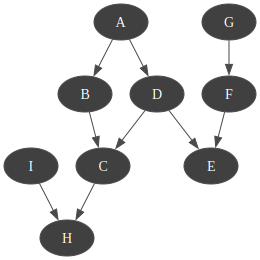

In [19]:
# Larger BN: A->B->C->H; I->H; A->D->C; D->E; G->F->E
bn_large = gum.fastBN("A->B->C->H;I->H;A->D->C;D->E;G->F->E", 2)
gnb.showBN(bn_large, size=8)

Full BN: 9 nodes, 9 qubits
Fragment: 6 nodes, 6 qubits


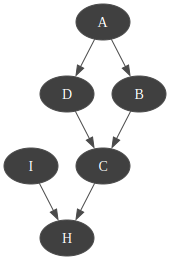

In [20]:
evidence_large = {"H": 0, "A": 1}
target = "D"

qbn_large = qBNS.qBNMC(bn_large)
qinf_large = qBNS.qBNRejection(qbn_large)
qinf_large.setEvidence(evidence_large)

# Restrict the circuit to the ancestors of {target} ∪ evidence
qinf_large.useFragmentBN(target={target})

print(f"Full BN: {bn_large.size()} nodes, {qbn_large.getTotNumQBits()} qubits")
print(f"Fragment: {qinf_large.qbn.bn.size()} nodes, {qinf_large.qbn.getTotNumQBits()} qubits")
gnb.showBN(qinf_large.qbn.bn)

In [21]:
qinf_large.setMaxIter(500)
qinf_large.makeInference()

ie_large = gum.LazyPropagation(bn_large)
ie_large.setEvidence(evidence_large)
ie_large.makeInference()

gnb.sideBySide(
  qinf_large.posterior(target),
  ie_large.posterior(target),
  captions=[f"qBNRejection — P({target} | H=0, A=1)", "LazyPropagation — exact"],
)

### Named example: 4-node Oil BN with evidence


In [22]:
bn_oil = gum.fastBN("IR->SM->SP<-OI", 2)
bn_oil.cpt("IR")[:] = [0.75, 0.25]
bn_oil.cpt("SM")[:] = [[0.3, 0.7], [0.8, 0.2]]
bn_oil.cpt("OI")[:] = [0.6, 0.4]
bn_oil.cpt("SP")[:] = [[[0.1, 0.9], [0.3, 0.7]], [[0.4, 0.6], [0.7, 0.3]]]

evidence_oil = {"SP": 1}
target_oil = "OI"

ie_oil = gum.LazyPropagation(bn_oil)
ie_oil.setEvidence(evidence_oil)
ie_oil.makeInference()
print(f"Exact P({target_oil} | SP=1) = {ie_oil.posterior(target_oil)}")

Exact P(OI | SP=1) = 
  OI               │
0        │1        │
─────────│─────────│
 0.7336  │ 0.2664  │



In [23]:
qbn_oil = qBNS.qBNMC(bn_oil)
qinf_oil = qBNS.qBNRejection(qbn_oil)
qinf_oil.setEvidence(evidence_oil)
qinf_oil.useFragmentBN(target={target_oil})
qinf_oil.setMaxIter(500)
qinf_oil.makeInference()

gnb.sideBySide(
  qinf_oil.posterior(target_oil),
  ie_oil.posterior(target_oil),
  captions=[f"qBNRejection — P({target_oil} | SP=1)", "LazyPropagation — exact"],
)

## QBN Summary

| Class | Purpose | Key method |
|---|---|---|
| `qBNMC` | Encode BN as quantum circuit | `buildCircuit()`, `runBN(shots)` |
| `qBNRejection` | Posterior inference with evidence | `setEvidence()`, `makeInference()`, `posterior(node)` |

Useful workflow:
1. Build `qBNMC(bn)` — circuit encoding.
2. Check marginals via `runBN()` (no evidence).
3. Build `qBNRejection(qbn)` and call `useFragmentBN(target, evidence)` to reduce circuit size.
4. `setEvidence()`, `setMaxIter()`, `makeInference()`, `posterior(node)`.
